In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\User_Purchase_Prediction_Dataset.xlsx")

In [3]:
df.head()

,User ID,Gender,Age,Salary,Purchased
0,100001,Female,24,115000,Yes
1,100002,Female,32,63000,No
2,100003,Male,20,130000,Yes
3,100004,Male,20,143000,Yes
4,100005,Male,42,60000,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    1000 non-null   int64 
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   int64 
 3   Salary     1000 non-null   int64 
 4   Purchased  1000 non-null   object
dtypes: int64(3), object(2)
memory usage: 39.2+ KB


In [5]:
df.describe()

,User ID,Age,Salary
count,1000.000000,1000.000000,1000.000000
mean,100500.500000,38.614000,82243.000000
std,288.819436,12.359683,40339.524393
min,100001.000000,18.000000,15000.000000
25%,100250.750000,28.000000,46000.000000
50%,100500.500000,38.000000,83000.000000
75%,100750.250000,49.000000,118250.000000
max,101000.000000,60.000000,150000.000000


In [8]:
df.shape

(1000, 5)

In [9]:
df.columns

Index(['User ID', 'Gender', 'Age', 'Salary', 'Purchased'], dtype='object')

In [12]:
df['Purchased'].value_counts()

Purchased
Yes    554
No     446
Name: count, dtype: int64

In [13]:
df['Gender'].value_counts()

Gender
Male      510
Female    490
Name: count, dtype: int64

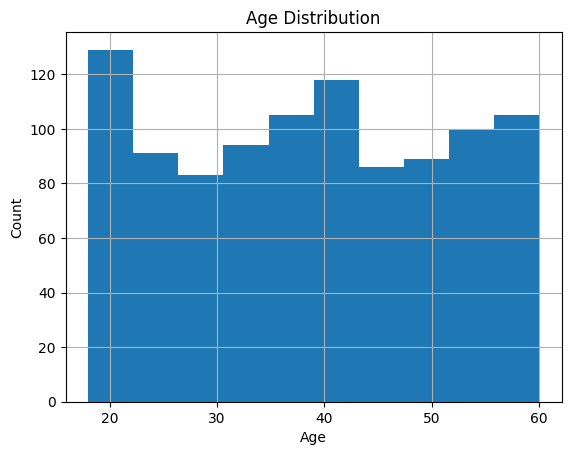

In [15]:
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
# Most customers are between 18 and 20 years old.

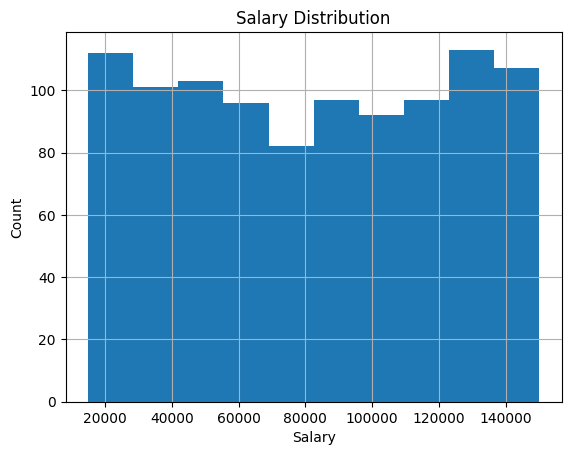

In [ ]:
df["Salary"].hist()
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()
#Most customers have salaries in the range of 20000-30000

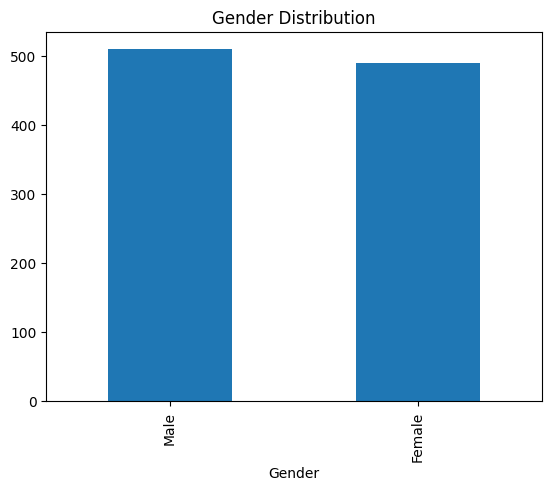

In [21]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()
#Male/Female customers are more common.

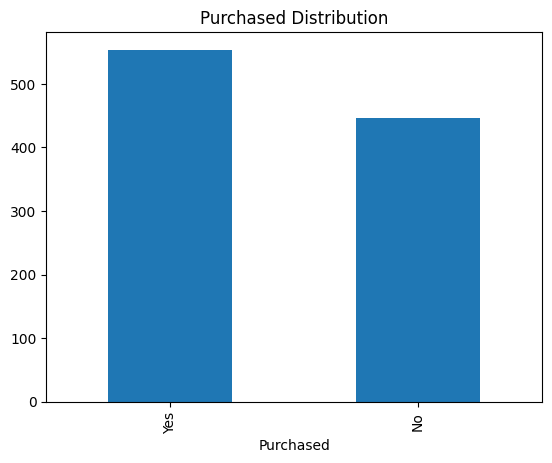

In [22]:
df["Purchased"].value_counts().plot(kind="bar")
plt.title("Purchased Distribution")
plt.show()
#More customers purchased / did not purchase.

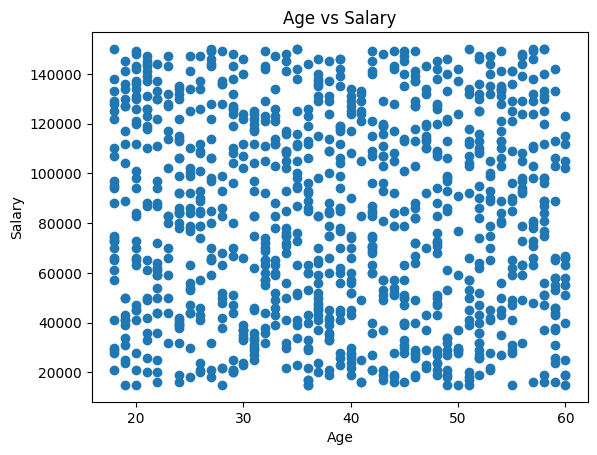

In [23]:
plt.scatter(df["Age"],df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder
lr = LabelEncoder()

In [29]:
df.columns

Index(['User ID', 'Gender', 'Age', 'Salary', 'Purchased'], dtype='object')

In [30]:
df['Gender'] = lr.fit_transform(df['Gender'])
#Female = 0 and Male Is= 1

In [33]:
df['Purchased'] = lr.fit_transform(df['Purchased'])
df.head()
#Yes = 1 & No = 0

,User ID,Gender,Age,Salary,Purchased
0,100001,0,24,115000,1
1,100002,0,32,63000,0
2,100003,1,20,130000,1
3,100004,1,20,143000,1
4,100005,1,42,60000,0


In [34]:
X = df[['Gender','Age','Salary']]
y = df['Purchased']


In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

In [41]:
knn_model.fit(X_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred = knn_model.predict(X_test)

In [44]:
compare = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
compare.head()

,Actual,Predicted
521,1,1
737,1,1
740,1,1
660,1,0
411,1,1


In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [54]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.89

In [47]:
confusion_matrix = confusion_matrix(y_test,y_pred)
confusion_matrix

array([[ 77,   9],
       [ 13, 101]])

In [48]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        86
           1       0.92      0.89      0.90       114

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [58]:
accuracy_scores = []

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test,prediction))

accuracy_scores

[0.865,
 0.86,
 0.865,
 0.86,
 0.89,
 0.875,
 0.88,
 0.86,
 0.875,
 0.865,
 0.875,
 0.87,
 0.885,
 0.895,
 0.89,
 0.895,
 0.88,
 0.885,
 0.88,
 0.88]

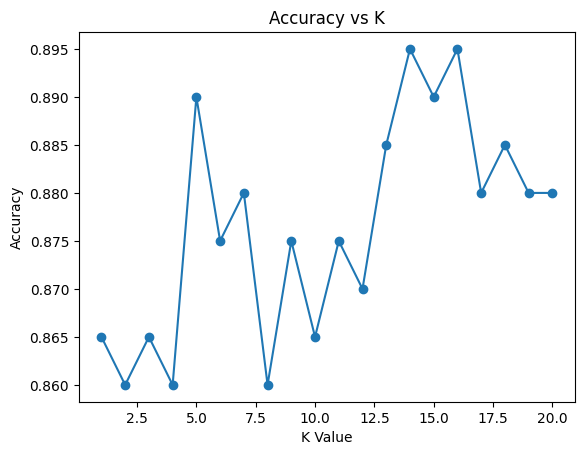

In [57]:
plt.plot(range(1,21),accuracy_scores,marker="o")

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.show()

In [62]:
new_customer1 = [[1,35,50000]]
new_customer = scaler.transform(new_customer)
prediction = knn.predict(new_customer)
print(prediction)

[0]


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [59]:
knn = KNeighborsClassifier(n_neighbors=14)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.895
[[ 77   9]
 [ 12 102]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88        86
           1       0.92      0.89      0.91       114

    accuracy                           0.90       200
   macro avg       0.89      0.90      0.89       200
weighted avg       0.90      0.90      0.90       200



In [60]:
new_customer1 = [[1,30,70000]]
new_customer = scaler.transform(new_customer)
prediction = knn.predict(new_customer)
print(prediction)

[0]


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
